## BAGIAN 1: CLASSIFICATION MODEL

### 1. Instalasi dan Persiapan Lingkungan

In [ ]:
!pip install -q datasets transformers evaluate accelerate torch openpyxl scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.1 MB/s eta 0:00:00


In [ ]:
# Import library
import os
import json
import pandas as pd
import numpy as np
import math
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import shutil
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from datasets import Dataset
from transformers import (
    BertTokenizerFast,
    BertConfig,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

In [ ]:
# Mengaktifkan format tabel interaktif
from google.colab import data_table
data_table.enable_dataframe_formatter()

In [ ]:
# Kunci Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [ ]:
# Cek GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

Menggunakan device: cuda


### 2. Load Dataset

Dataset yang digunakan dalam penelitian ini berasal dari hasil anotasi dan semi-otomatis yang telah dilakukan verifikasi oleh anotator atau pakar yang diberi nama Corpus IndoSE. Dataset ini berformat excel (.xlsx) yang terdiri dari 1.881 baris data dan 4 kolom.

**Variabel-variabel pada Corpus IndoSE dataset adalah sebagai berikut :**

- abstract_id : ID abstrak
- sentence_no : Nomor kalimat
- sentence_segment : Kalimat abstrak
- label_pmrc : Kelas struktur retoris

In [ ]:
# Load Dataset IndoSE
file_path = "/content/corpus_indose.xlsx"
data_pmrc = pd.read_excel(file_path, sheet_name='Sheet1')
data_pmrc.head(9)

,abstract_id,sentence_no,sentence_segment,label_pmrc
0,1,1,klinik pratama sebagai fasilitas layanan keseh...,no_pmrc
1,1,2,klinik pratama dr anton selaku objek penelitia...,problem
2,1,3,penelitian ini bertujuan untuk menghasilkan pr...,result
3,1,4,ruang lingkup penelitian ini pada pengembangan...,method
4,1,5,metode dalam penelitian ini meliputi pengumpul...,method
5,1,6,penelitian bersifat kualitatif dengan metode d...,method
6,1,7,pengembangan sistem menerapkan konsep waterfal...,method
7,1,8,penelitian menghasilkan produk komputer pengol...,result
8,1,9,kesimpulan penelitian ini sudah mampu menghasi...,conclusion


In [ ]:
# Menampilkan informasi dataset
data_pmrc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1881 entries, 0 to 1880
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   abstract_id       1881 non-null   int64 
 1   sentence_no       1881 non-null   int64 
 2   sentence_segment  1881 non-null   object
 3   label_pmrc        1881 non-null   object
dtypes: int64(2), object(2)
memory usage: 58.9+ KB


In [ ]:
# Menampilkan jumlah abstrak
print("Jumlah abstract_id:", len(data_pmrc['abstract_id'].unique()))

Jumlah abstract_id: 250


Berdasarkan informasi dataset, seluruh kolom memiliki 4 kolom dan 1.881 baris data non-null yang mengonfirmasi bahwa data sudah bersih dari nilai yang hilang (missing values). Keseluruhan teks tersebut merupakan hasil ekstraksi struktur kalimat dari 250 dokumen abstrak ilmiah secara utuh.

In [ ]:
# Menentukan urutan custom
label_names = ['problem', 'method', 'result', 'conclusion', 'no_pmrc']

# Menampilkan jumlah data pada label_pmrc
print("Class Distribution")
sorted_counts = data_pmrc['label_pmrc'].value_counts().reindex(label_names)
sorted_counts.head()

Class Distribution


,count
label_pmrc,
problem,370
method,547
result,333
conclusion,163
no_pmrc,468


Hasil output menunjukkan adanya masalah ketidakseimbangan data (*imbalanced data*) yang signifikan antara kelas mayoritas—*method* (547 sampel) dan *no_pmrc* (468 sampel)—dengan kelas minoritas yaitu *conclusion* (163 sampel). Ketimpangan ini berisiko membuat model (seperti IndoBERT) mengalami bias karena cenderung memprioritaskan kelas mayoritas selama pelatihan. Oleh karena itu, diperlukan teknik data balancing melalui penerapan bobot kelas (*class weight*) pada *loss function* untuk menyeimbangkan perhatian model terhadap seluruh kelas PMRC.

### 3. Mapping Label dan Hitung Class Weight

Pada tahap ini, dilakukan proses standardisasi teks dan pemetaan (mapping) label kategori tekstual menjadi representasi numerik agar dapat diproses oleh model.

In [ ]:
# Mapping label
label_names = ['problem', 'method', 'result', 'conclusion', 'no_pmrc']
label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for i, label in enumerate(label_names)}

# Mengubah teks di label_pmrc menjadi angka di kolom 'label'
data_pmrc['label'] = data_pmrc['label_pmrc'].str.lower().str.strip().map(label2id)
data_pmrc.head(9)

,abstract_id,sentence_no,sentence_segment,label_pmrc,label
0,1,1,klinik pratama sebagai fasilitas layanan keseh...,no_pmrc,4
1,1,2,klinik pratama dr anton selaku objek penelitia...,problem,0
2,1,3,penelitian ini bertujuan untuk menghasilkan pr...,result,2
3,1,4,ruang lingkup penelitian ini pada pengembangan...,method,1
4,1,5,metode dalam penelitian ini meliputi pengumpul...,method,1
5,1,6,penelitian bersifat kualitatif dengan metode d...,method,1
6,1,7,pengembangan sistem menerapkan konsep waterfal...,method,1
7,1,8,penelitian menghasilkan produk komputer pengol...,result,2
8,1,9,kesimpulan penelitian ini sudah mampu menghasi...,conclusion,3


In [ ]:
# Menghitung Class Weights
classes = np.unique(data_pmrc['label'].values)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=data_pmrc['label'].values
)
class_weights_tensor = torch.tensor(weights, dtype=torch.float)

width = 50
print("=" * width)
print(f"Class Weight Distribution".center(width))
print("=" * width)

for name, weight in zip(label_names, weights):
    count = len(data_pmrc[data_pmrc['label'] == label2id[name]])
    print(f"{name:<12}: {count:5} samples | Weight : {weight:^5.4f}")
print("-" * width)

            Class Weight Distribution             
problem     :   370 samples | Weight : 1.0168
method      :   547 samples | Weight : 0.6878
result      :   333 samples | Weight : 1.1297
conclusion  :   163 samples | Weight : 2.3080
no_pmrc     :   468 samples | Weight : 0.8038
--------------------------------------------------


Berdasarkan output di atas, perhitungan dengan metode *balanced* berhasil memberikan bobot yang berbanding terbalik dengan jumlah sampel. Kelas mayoritas seperti *method* dan *no_pmrc* mendapatkan bobot terendah (masing-masing 0.6878 dan 0.8038), sedangkan kelas minoritas *conclusion* mendapat bobot tertinggi sebesar 2.3080, diikuti kelas *problem* (1.0168) dan *result* (1.1297) yang berada di posisi tengah. Dengan mengonversi nilai-nilai ini menjadi class_weights_tensor pada *loss function* PyTorch, model dipaksa menerima penalti kesalahan yang lebih besar saat salah memprediksi kelas minoritas, sehingga performa klasifikasi akhir dapat dievaluasi secara adil dan seimbang untuk seluruh kelas PMRC.

### 4. Inisialisasi Tokenizer dan Fungsi Tokenisasi

Pada tahap ini, dilakukan pra-pemrosesan teks (*text preprocessing*) menggunakan *tokenizer* **indobenchmark/indobert-base-p1** untuk mengubah kalimat mentah abstrak menjadi format numerik. Proses ini dikonfigurasi dengan panjang maksimal (*max_length*) 128 token, serta mengaktifkan fitur pemotongan (*truncation*) dan pengisian (*padding*) agar menghasilkan dimensi data yang seragam.

In [ ]:
# Inisialisasi tokenizer IndoBERT
tokenizer = BertTokenizerFast.from_pretrained("indobenchmark/indobert-base-p1")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Fungsi tokenisasi dataset (penyiapan input model)
def tokenize_function(examples):
    return tokenizer(examples["sentence_segment"], truncation=True, padding="max_length", max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# Menampilkan satu sampel representatif untuk setiap kelas label (0 hingga 4)
print("="*30 + " REPRESENTATIVE INSPECTION LABEL " + "="*30)

temp_df = data_pmrc.copy()

# Tokenisasi data menggunakan tokenize_function dan tokenizer yang telah ditentukan sebelumnya
temp_dataset = Dataset.from_pandas(temp_df).map(tokenize_function, batched=True)

target_labels = [0, 1, 2, 3, 4]
found_indices = []

# Mencari indeks kemunculan pertama untuk setiap label target
for target in target_labels:
    found = False
    for idx, sample in enumerate(temp_dataset):
        if sample['label'] == target:
            found_indices.append(idx)
            found = True
            break
    if not found:
        print(f"Warning: Label {target} not found in the dataset for display. Skipping this label.")

# Lakukan iterasi dan periksa detail tokenisasi struktural untuk setiap label yang ditemukan
for idx in found_indices:
    sample = temp_dataset[idx]
    raw_text = temp_df.iloc[idx]['sentence_segment']
    tokens = tokenizer.convert_ids_to_tokens(sample['input_ids'])

    print(f"\n[ LABEL EXAMPLE: {sample['label']} ({sample['label_pmrc']}) ]")
    print(f"Sentence       : {raw_text}")
    print("-" * 50)
    print(f"Token IDs      : {sample['input_ids']}")
    print(f"Attention Mask : {sample['attention_mask']}")
    print(f"Token          : {tokens}")
    if 'token_type_ids' in sample:
        print(f"Token Type IDs : {sample['token_type_ids']}")

    print("-" * 50)
    print(f"Decoded        : {tokenizer.decode(sample['input_ids'])}")
    print("=" * 80)

============================== REPRESENTATIVE INSPECTION LABEL ==============================


Map:   0%|          | 0/1881 [00:00<?, ? examples/s]


[ LABEL EXAMPLE: 0 (problem) ]
Sentence       : klinik pratama dr anton selaku objek penelitian memiliki permasalahan dalam pengelolaan data rekam medis diantaranya kunjungan pasien per hari tinggi, pencatatan dan pengolahan data rekam medis masih manual, sehingga masih banyak data yang tidak berkesinambungan dan kesulitan dalam rekapitulasi laporan.
--------------------------------------------------
Token IDs      : [2, 7810, 12730, 1008, 15319, 6213, 2113, 1296, 343, 3472, 112, 3468, 1006, 13969, 5049, 3262, 4190, 2703, 62, 406, 717, 30468, 11430, 41, 5169, 1006, 13969, 5049, 419, 5603, 30468, 485, 419, 271, 1006, 34, 119, 14771, 10585, 41, 3723, 112, 22457, 2490, 30470, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention Mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

Hasil inspeksi menunjukkan bahwa tokenizer berhasil mengekstrak komponen Token IDs, Token Type IDs, dan Attention Mask (bernilai 1 untuk kata asli dan 0 untuk token [PAD]). Selain itu, model secara otomatis menyisipkan token khusus [CLS] di awal kalimat sebagai fitur klasifikasi dan [SEP] di akhir kalimat, serta menerapkan metode *Subword Tokenization (WordPiece)* yang mampu memecah kata kompleks menjadi sub-kata, seperti kata "komputerisasi" menjadi ['komputer', '##isasi']

### 5. Trainer (Custom) dan  Fungsi Evaluasi

Untuk mengintegrasikan bobot kelas yang telah dihitung sebelumnya, dibuat kelas kustom CustomTrainer yang mewarisi Trainer dari Hugging Face. Modifikasi ini dilakukan dengan meng-*override* fungsi compute_loss menggunakan nn.CrossEntropyLoss yang dikonfigurasi dengan class_weights_tensor. Langkah ini memastikan model menerima penalti *error* yang lebih besar saat salah memprediksi kelas minoritas selama *forward pass*, sehingga model menjadi lebih sensitif terhadap kelas yang kekurangan sampel.

In [ ]:
# Custom Trainer untuk menangani ketidakseimbangan kelas menggunakan Weighted Cross-Entropy Loss
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        # Proses forward pass
        outputs = model(**inputs)
        # Ekstraksi logits berdasarkan struktur output model
        if hasattr(outputs, "logits"):
            logits = outputs.logits
        else:
            logits = outputs["logits"]
        # Menghitung loss menggunakan bobot kelas yang telah ditentukan
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

Selanjutnya, fungsi compute_metrics dibuat untuk mengevaluasi kinerja prediksi model pada setiap akhir epoch atau steps. Fungsi ini menggunakan np.argmax(logits, axis=-1) untuk menentukan kelas prediksi, lalu menghitung akurasi dan F1-score macro. Penggunaan parameter average="macro" sangat penting untuk menilai performa setiap kelas secara independen, sehingga menjadi indikator yang adil dan objektif dalam mengukur keberhasilan penanganan bias model tanpa terpengaruh oleh dominasi kelas mayoritas.

In [ ]:
# Fungsi evaluasi untuk menghitung metrik performa model selama pelatihan
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

### 6. Konfigurasi K-Fold

Pada tahap ini, dilakukan pembagian data menggunakan teknik *10-Fold Stratified Cross-Validation* pada total dataset sebanyak 1.881 sampel. Hal ini bertujuan untuk mencegah terjadinya bias akibat ketimpangan distribusi kelas (*imbalance data*).

In [ ]:
# Konfigurasi 10-Fold Stratified Cross-Validation
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

texts = data_pmrc['sentence_segment'].tolist()
labels = data_pmrc['label'].tolist()

# Melakukan pembagian indeks data berdasarkan teks dan label target
fold_indices = list(skf.split(texts, labels))
print(f"\n✅ Ready to run {n_splits}-Fold Cross Validation. Total Data: {len(data_pmrc)}")


✅ Ready to run 10-Fold Cross Validation. Total Data: 1881


In [ ]:
# Verifikasi hasil pembagian data untuk setiap fold pada Cross-Validation
print(f"{'Fold':<10} | {'Train Size':^12} | {'Val Size':^10}")
print("-" * 40)

# Menampilkan ukuran data training dan validation per fold
for fold, (train_idx, val_idx) in enumerate(fold_indices):
    print(f"Fold {fold+1:<5} | {len(train_idx):^12} | {len(val_idx):^10}")

print("-" * 40)
print(f"Total Data: {len(data_pmrc)}".center(40))
print("-" * 40)
print(f"✅ Preparation Completed.")

Fold       |  Train Size  |  Val Size 
----------------------------------------
Fold 1     |     1692     |    189    
Fold 2     |     1693     |    188    
Fold 3     |     1693     |    188    
Fold 4     |     1693     |    188    
Fold 5     |     1693     |    188    
Fold 6     |     1693     |    188    
Fold 7     |     1693     |    188    
Fold 8     |     1693     |    188    
Fold 9     |     1693     |    188    
Fold 10    |     1693     |    188    
----------------------------------------
            Total Data: 1881            
----------------------------------------
✅ Preparation Completed.


In [ ]:
# Menampilkan distribusi label target untuk seluruh fold
print(f"🔍 LABEL DISTRIBUTION FOR {n_splits} FOLDS\n")

for i in range(0, n_splits, 2):
    lines = ["", "", "", "", ""]
    for j in range(2):
        fold_idx = i + j
        if fold_idx >= n_splits: break

        train_idx, val_idx = fold_indices[fold_idx]

        # Menghitung frekuensi label_pmrc pada subset data training dan validation
        train_labels = data_pmrc.iloc[train_idx]['label_pmrc'].value_counts()
        val_labels = data_pmrc.iloc[val_idx]['label_pmrc'].value_counts()
        train_dist = train_labels.reindex(label_names).fillna(0).astype(int)
        val_dist = val_labels.reindex(label_names).fillna(0).astype(int)

        # Menyusun komponen layout tabel
        width = 50
        sep = "    ║    " if j == 0 else ""

        lines[0] += f"{'=' * width}".ljust(width) + sep
        lines[1] += f"FOLD {fold_idx + 1} DISTRIBUTIONS".center(width) + sep
        lines[2] += f"{'-' * width}".ljust(width) + sep
        lines[3] += f"{'Label':<16} | {'Train':^12} | {'Val':^12}".ljust(width) + sep
        lines[4] += f"{'-' * width}".ljust(width) + sep

        # Menggabungkan baris data distribusi ke dalam struktur teks tabel
        for idx, label in enumerate(label_names):
            data_row = f"{label:<16} | {train_dist[label]:^12} | {val_dist[label]:^12}"
            if len(lines) <= 5 + idx:
                lines.append(data_row.ljust(width) + sep)
            else:
                lines[5 + idx] += data_row.ljust(width) + sep

        # Menyusun bagian bawah (footer) tabel untuk menampilkan total data
        footer_idx = 5 + len(label_names)
        total_text = f"Total Data: Train={len(train_idx)} | Val={len(val_idx)}"

        if len(lines) <= footer_idx:
            lines.append("-" * width + sep)
            lines.append(total_text.center(width) + sep)
            lines.append("=" * width + sep)
        else:
            lines[footer_idx] += ("-" * width).ljust(width) + sep
            lines[footer_idx+1] += total_text.center(width) + sep
            lines[footer_idx+2] += ("=" * width).ljust(width) + sep

    # Mencetak representasi string tabel yang telah digabungkan per baris
    for line in lines:
        print(line)
    print("\n")

🔍 LABEL DISTRIBUTION FOR 10 FOLDS

==================================================    ║    ==================================================
               FOLD 1 DISTRIBUTIONS                   ║                   FOLD 2 DISTRIBUTIONS               
--------------------------------------------------    ║    --------------------------------------------------
Label            |    Train     |     Val             ║    Label            |    Train     |     Val         
--------------------------------------------------    ║    --------------------------------------------------
problem          |     333      |      37             ║    problem          |     333      |      37         
method           |     493      |      54             ║    method           |     492      |      55         
result           |     299      |      34             ║    result           |     300      |      33         
conclusion       |     146      |      17             ║    conclusion       |     147

Proses partisi berhasil membagi data secara konsisten dan proporsional di setiap fold, dengan ukuran subset data training berkisar antara 1.692–1.693 sampel dan data validation sebanyak 188–189 sampel. Distribusi lima kelas target (problem, method, result, conclusion, dan no_pmrc) juga secara konsisten dan seimbang (homogen) di seluruh subset train maupun validation pada setiap iterasi fold.

### 7. Proses dan Eksekusi Training (Loop K-Fold)

Pada tahap ini, dilakukan proses pelatihan dan evaluasi model klasifikasi teks berbasis **indobert-base-p1** menggunakan *10-Fold Stratified K-Fold Cross-Validation*. Eksperimen ini mengintegrasikan beberapa teknik regulasi dan strategi optimasi untuk mencegah risiko overfitting, seperti penyesuaian nilai dropout sebesar 0.3 pada lapisan hidden dan attention, penerapan penjadwal laju pembelajaran berupa *Cosine Learning Rate Scheduler* dengan durasi *warmup step*s sebesar 15% dari total langkah pelatihan, serta mekanisme *Early Stopping* dengan toleransi *(patience*) sebanyak 5 langkah evaluasi.

In [ ]:
# Membuat struktur folder untuk menyimpan model dan evaluasi di penyimpanan Colab
EXP_NAME = "indobert-pmrc"
BASE_PATH = f"/content/{EXP_NAME}"
os.makedirs(f"{BASE_PATH}/model", exist_ok=True)
os.makedirs(f"{BASE_PATH}/reports", exist_ok=True)
os.makedirs(f"{BASE_PATH}/results", exist_ok=True)

In [ ]:
# Inisialisasi variabel global untuk menyimpan log metrik dan prediksi
all_fold_metrics = []
all_oof_predictions = []
all_fold_histories = []

# Tracker untuk menyimpan performa dan data dari model terbaik
best_f1 = 0
best_fold_number = 0
best_oof_df = pd.DataFrame()
best_train_df = pd.DataFrame()

# Hiperparameter regulasi untuk memitigasi overfitting
batch_size = 16
epochs = 10
learning_rate = 3e-6
dropout_prob = 0.3

# Eksekusi Stratified K-Fold Cross-Validation Loop
for fold, (train_idx, val_idx) in enumerate(fold_indices):
    current_fold = fold + 1
    print(f"\n{'='*50}\n{f'🚀 RUNNING FOLD {current_fold} / {n_splits}':^45}\n{'='*50}")

    # A. Data preparation
    train_df_fold = data_pmrc.iloc[train_idx].copy().reset_index(drop=True)
    val_df_fold = data_pmrc.iloc[val_idx].copy().reset_index(drop=True)

    train_ds = Dataset.from_pandas(train_df_fold).map(tokenize_function, batched=True)
    val_ds = Dataset.from_pandas(val_df_fold).map(tokenize_function, batched=True)

    # B. Perhitungan warmup_steps
    total_train_steps = (len(train_ds) // batch_size) * epochs
    warmup_steps = int(0.15 * total_train_steps)

    # C. # Inisialisasi konfigurasi model dengan penyesuaian nilai dropout
    config = BertConfig.from_pretrained(
        "indobenchmark/indobert-base-p1",
        num_labels=len(label_names),
        id2label=id2label,
        label2id=label2id
    )
    config.hidden_dropout_prob = dropout_prob
    config.attention_probs_dropout_prob = dropout_prob

    model = BertForSequenceClassification.from_pretrained(
        "indobenchmark/indobert-base-p1",
        config=config
    ).to(device)

    # D. Mengatur argumen training
    training_args = TrainingArguments(
        output_dir=f"./temp_checkpoints/fold_{current_fold}",
        save_strategy="steps",
        save_steps=500,
        save_total_limit=1,
        load_best_model_at_end=True,

        logging_strategy="steps",
        logging_steps=100,
        eval_strategy="steps",
        eval_steps=100,
        metric_for_best_model="f1_macro",
        greater_is_better=True,

        learning_rate=learning_rate,
        weight_decay=0.5,
        lr_scheduler_type="cosine",
        warmup_steps=warmup_steps,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,

        fp16=True,
        report_to="none",
        seed=42,
        full_determinism=True
    )

    trainer = CustomTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
    )

    # E. Proses training
    train_result = trainer.train()
    fold_training_time = train_result.metrics["train_runtime"]

    # F. Visualisasi distribusi label untuk fold aktif
    train_dist = train_df_fold['label_pmrc'].value_counts().reindex(label_names).fillna(0).astype(int)
    val_dist = val_df_fold['label_pmrc'].value_counts().reindex(label_names).fillna(0).astype(int)

    width = 45
    print(f"\n{'='*width}\n{f'🚀 FOLD {current_fold} / {n_splits}':^45}\n{'='*width}")
    print(f"{'Label':<15} | {'Train':^12} | {'Val':^12}")
    print("-" * width)
    for label in label_names:
        print(f"{label:<15} | {train_dist[label]:^12} | {val_dist[label]:^12}")
    print("-" * width)
    total_text = f"Total Data: Train={len(train_idx)} | Val={len(val_idx)}"
    print(f"{total_text}")
    print("-" * width)

    # G. Evaluasi performa fold dan pembuatan Out-of-Fold (OOF) predictions
    eval_metrics = trainer.evaluate()
    eval_metrics['Training Time (s)'] = fold_training_time
    eval_metrics['Fold'] = current_fold

    all_fold_metrics.append(eval_metrics)
    all_fold_histories.append(trainer.state.log_history)

    # Ekstraksi probabilitas prediksi menggunakan fungsi Softmax
    raw_pred = trainer.predict(val_ds)
    probs = F.softmax(torch.from_numpy(raw_pred.predictions), dim=-1)
    conf_scores, preds = torch.max(probs, dim=-1)

    val_df_fold['fold'] = current_fold
    val_df_fold['predicted_label'] = [id2label[p.item()] for p in preds]
    val_df_fold['confidence_score'] = conf_scores.numpy()
    val_df_fold['is_correct'] = val_df_fold['label_pmrc'].str.lower() == val_df_fold['predicted_label'].str.lower()
    all_oof_predictions.append(val_df_fold)

    print(f"✅ Fold {current_fold} - Acc: {eval_metrics['eval_accuracy']:.4f} | F1: {eval_metrics['eval_f1_macro']:.4f} | Time: {fold_training_time:.2f} s")
    print("-" * width)

    # H. Validasi dan penyimpanan checkpoint model terbaik berdasarkan metrik Macro F1
    if eval_metrics['eval_f1_macro'] > best_f1:
        if best_fold_number != 0:
            old_save_path = f"{BASE_PATH}/model/best_model_fold_{best_fold_number}"
            if os.path.exists(old_save_path):
                shutil.rmtree(old_save_path)
                print(f"🗑️ Deleted previous best model: Fold {best_fold_number}")

        best_f1 = eval_metrics['eval_f1_macro']
        best_fold_number = current_fold
        best_oof_df = val_df_fold.copy()
        best_train_df = train_df_fold.copy()
        best_train_df['fold'] = current_fold

        new_save_path = f"{BASE_PATH}/model"

        trainer.save_model(new_save_path)
        tokenizer.save_pretrained(new_save_path)

        # Mencatat metadata eksperimen ke file info_model.txt
        with open(f"{new_save_path}/info_model.txt", "w") as f:
            f.write("="*70 + "\n")
            f.write("BEST MODEL CONFIGURATION\n")
            f.write("="*70 + "\n")
            info = {
                "Best Fold Source": best_fold_number,
                "F1-Macro": f"{best_f1:.4f}",
                "Accuracy": f"{eval_metrics['eval_accuracy']:.4f}",
                "Loss": f"{eval_metrics['eval_loss']:.4f}",
                "Training Time": f"{fold_training_time:.2f} s",
                "Base Model": "indobenchmark/indobert-base-p1",
                "Epochs": epochs,
                "Learning Rate": learning_rate,
                "Batch Size": batch_size,
                "Warmup Steps": warmup_steps,
                "Weight Decay": "0.5",
                "Hidden Dropout": dropout_prob,
                "LR Scheduler": "cosine",
                "Early Stopping": "Patience 5",
                "Seed": 42
            }
            for key, val in info.items():
                f.write(f"{key:<18}: {val}\n")

            f.write("-" * 30 + "\n")
            f.write(f"Label Map: {id2label}\n")

        print(f"⭐ Fold {current_fold} is the new best model!")

    # I. Manajemen alokasi memori dengan membersihkan cache VRAM GPU
    del model, trainer, train_ds, val_ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Pembersihan direktori lokal sementara setelah seluruh proses selesai
shutil.rmtree('./temp_checkpoints', ignore_errors=True)
print("\n✅ All Folds have been trained with New Regularization Settings!")


            🚀 RUNNING FOLD 1 / 10            


Map:   0%|          | 0/1692 [00:00<?, ? examples/s]

Map:   0%|          | 0/189 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134: UserWarning: Requested unified CUBLASLT workspace size of 1048576 bytes exceeds CUBLAS workspace size of 131072 bytes. Please increase CUBLAS workspace size via CUBLAS_WORKSPACE_CONFIG or decrease requested CUBLASLT_WORKSPACE_SIZE. Otherwise CUBLASLT workspace size will be limited to the CUBLAS workspace size. (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:228.)
  return F.linear(input, self.weight, self.bias)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


               🚀 FOLD 10 / 10                
Label           |    Train     |     Val     
---------------------------------------------
problem         |     333      |      37     
method          |     493      |      54     
result          |     299      |      34     
conclusion      |     146      |      17     
no_pmrc         |     422      |      46     
---------------------------------------------
Total Data: Train=1693 | Val=188
---------------------------------------------


Training Loss,Validation Loss,Step,Accuracy,F1 Macro
0.748521,0.789353,1060,0.712766,0.689826


✅ Fold 10 - Acc: 0.7128 | F1: 0.6898 | Time: 255.61 s
---------------------------------------------

✅ All Folds have been trained with New Regularization Settings!


Pada setiap iterasi fold, data dikonversi ke dalam format Hugging Face Dataset, dilatih menggunakan CustomTrainer, lalu performanya dilacak melalui metrik evaluasi F1-Macro dan akurasi global. Selama looping berjalan, kode ini secara otomatis melakukan pelacakan prediksi *Out-of-Fold* (OOF) menggunakan fungsi Softmax untuk mencatat skor kepercayaan (confidence score), mengisolasi bobot model terbaik dari fold yang paling optimal untuk disimpan ke direktori lokal beserta file metadata info_model.txt, serta membersihkan alokasi memori VRAM GPU menggunakan torch.cuda.empty_cache() untuk mencegah terjadinya eror Out-of-Memory (OOM).

### 8. Evaluasi Agregat (10-Fold CV)

Pada tahap ini, dilakukan analisis evaluasi menyeluruh terhadap performa model berdasarkan *10-Fold Cross-Validation*

#### A. Evaluasi Statistik

In [ ]:
# Ekstraksi metrik evaluasi dan durasi komputasi dari seluruh fold
all_accuracies = [m['eval_accuracy'] for m in all_fold_metrics]
all_f1_macros = [m['eval_f1_macro'] for m in all_fold_metrics]
all_times = [m['Training Time (s)'] for m in all_fold_metrics]

# Kalkulasi statistik deskriptif (Mean dan Standard Deviation)
mean_acc, std_acc = np.mean(all_accuracies), np.std(all_accuracies)
mean_f1, std_f1 = np.mean(all_f1_macros), np.std(all_f1_macros)
mean_time, std_time = np.mean(all_times), np.std(all_times)

# Visualisasi tabel rekapitulasi performa model akhir (10-Fold CV)
table_width = 57
print("\n" + "=" * table_width)
print(f"{'':<12} | {'Accuracy':^12} | {'F1-Macro':^12} | {'Time (s)':^12}")
print("-" * table_width)

# Menampilkan metrik performa individu untuk tiap fold
for i in range(len(all_accuracies)):
    print(f"{f'Fold {i+1}':<12} | {all_accuracies[i]:^12.4f} | {all_f1_macros[i]:^12.4f} | {all_times[i]:^12.2f}")

print("-" * table_width)

# Menampilkan akumulasi nilai rata-rata dan standar deviasi seluruh fold
print(f"{'Mean':<12} | {mean_acc:^12.4f} | {mean_f1:^12.4f} | {mean_time:^12.2f}")
print(f"{'Std Dev':<12} | {f'±{std_acc:.4f}':^12} | {f'±{std_f1:.4f}':^12} | {f'±{std_time:.2f}':^12}")
print("=" * table_width)

print(f"🏆 BEST MODELS SAVED FROM: FOLD {best_fold_number} (F1: {best_f1:.4f})")
print("=" * table_width + "\n")


             |   Accuracy   |   F1-Macro   |   Time (s)  
---------------------------------------------------------
Fold 1       |    0.6561    |    0.6308    |    189.30   
Fold 2       |    0.7128    |    0.6703    |    238.47   
Fold 3       |    0.7074    |    0.6983    |    219.49   
Fold 4       |    0.6436    |    0.6173    |    206.09   
Fold 5       |    0.6862    |    0.6710    |    227.31   
Fold 6       |    0.7394    |    0.7092    |    169.37   
Fold 7       |    0.6596    |    0.6244    |    231.91   
Fold 8       |    0.7447    |    0.7267    |    165.55   
Fold 9       |    0.7394    |    0.7204    |    283.93   
Fold 10      |    0.7128    |    0.6898    |    255.61   
---------------------------------------------------------
Mean         |    0.7002    |    0.6758    |    218.70   
Std Dev      |   ±0.0352    |   ±0.0381    |    ±35.41   
🏆 BEST MODELS SAVED FROM: FOLD 8 (F1: 0.7267)



- Secara keseluruhan, model menunjukkan stabilitas performa yang baik dengan pencapaian rata-rata (*Mean*) akurasi global sebesar 0.7002 ($\pm$0.0352) dan skor F1-Macro sebesar 0.6758 ($\pm$0.0381). Nilai standar deviasi yang relatif rendah pada kedua metrik tersebut mengindikasikan bahwa model memiliki kemampuan generalisasi yang konsisten dan tidak sensitif terhadap variasi partisi data pada setiap fold.
- Adapun performa optimal dicapai pada Fold 8 dengan skor akurasi tertinggi sebesar 0.7447 dan F1-Macro sebesar 0.7267 dalam waktu komputasi 165.55 detik, menjadikannya sebagai checkpoint model terbaik (Best Model) yang diisolasi dan disimpan untuk kebutuhan inferensi selanjutnya.

#### B. Evaluasi Loss Curve

📊 VISUALISASI PERBANDINGAN LOSS



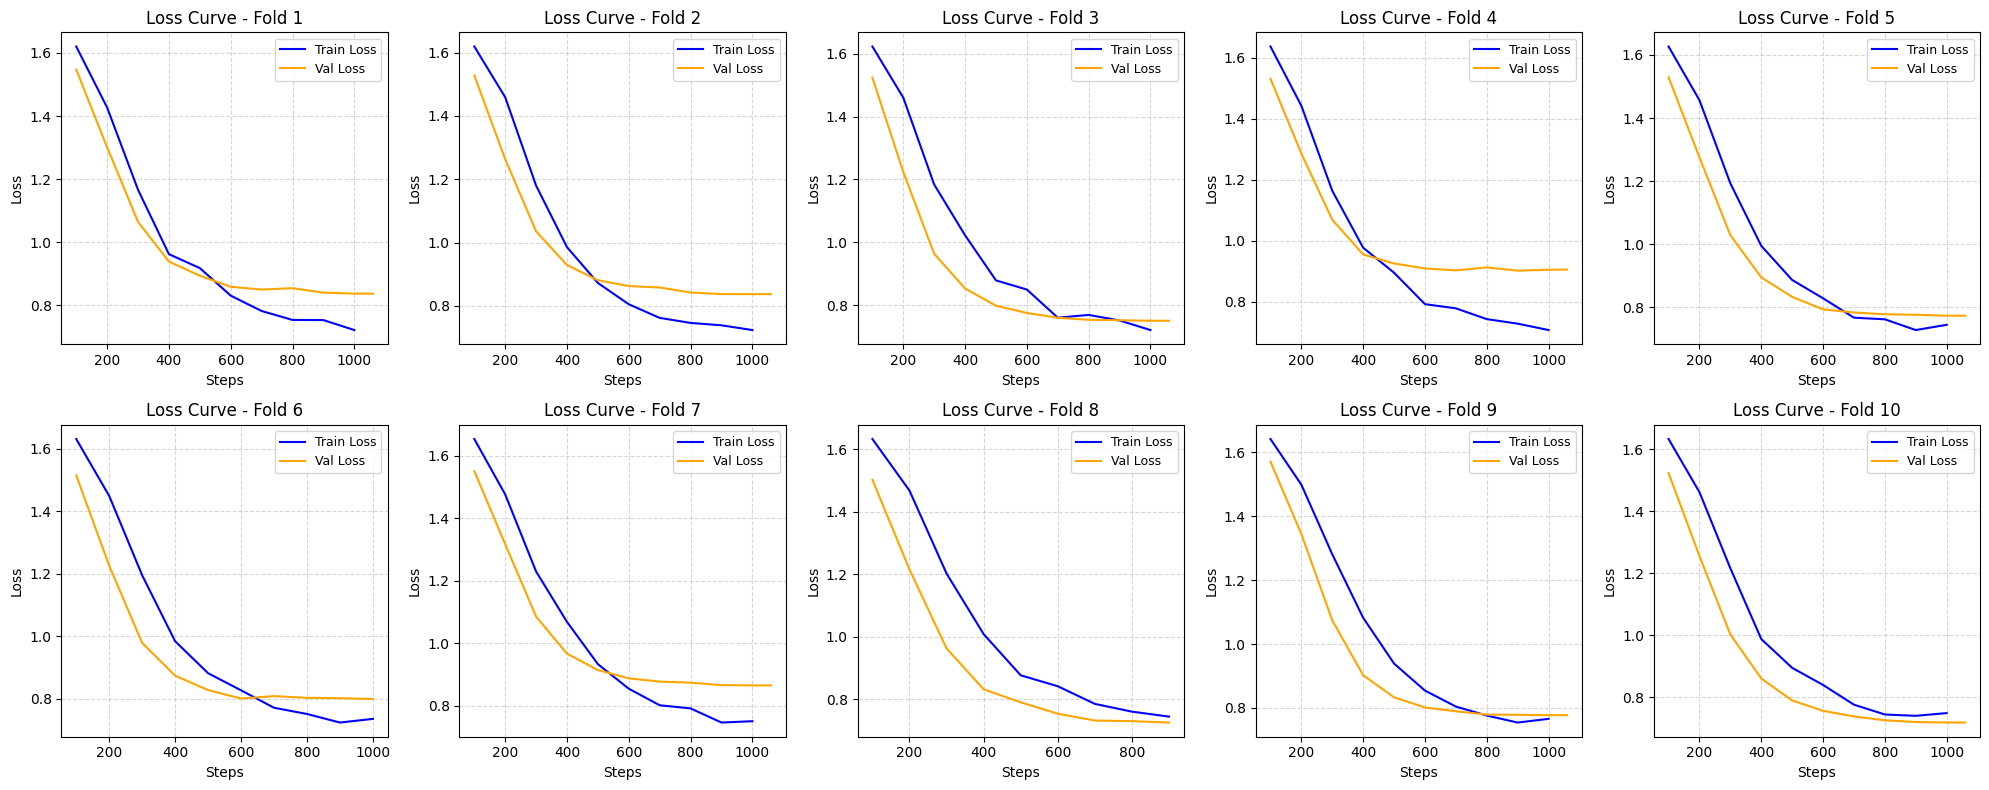

In [ ]:
history = all_fold_histories[-1]
train_loss = [e['loss'] for e in history if 'loss' in e]
val_loss = [e['eval_loss'] for e in history if 'eval_loss' in e]

# Menentukan dimensi grid subplot secara dinamis berdasarkan jumlah fold
print("📊 VISUALISASI PERBANDINGAN LOSS\n")

num_folds = len(all_fold_histories)
num_cols = 5
num_rows = math.ceil(num_folds / num_cols)

plt.figure(figsize=(20, 4 * num_rows))

# Melakukan iterasi untuk setiap fold di dalam list history
for idx, history in enumerate(all_fold_histories):

    # 1. Ekstrak metrik dan langkah (steps) latihan dengan mitigasi duplikasi data
    train_steps = []
    train_loss = []
    for e in history:
        if 'loss' in e and 'step' in e:
            if e['step'] not in train_steps:
                train_steps.append(e['step'])
                train_loss.append(e['loss'])

    # Ekstrak metrik dan langkah validasi dengan mitigasi duplikasi data
    val_steps = []
    val_loss = []
    for e in history:
        if 'eval_loss' in e and 'step' in e:
            if e['step'] not in val_steps:
                val_steps.append(e['step'])
                val_loss.append(e['eval_loss'])

    # 2. Konfigurasi penempatan grafik pada grid subplot
    plt.subplot(num_rows, num_cols, idx + 1)

    # 3. Pembuatan grafik garis untuk perbandingan Train Loss dan Validation Loss
    plt.plot(train_steps, train_loss, label='Train Loss', color='blue')
    plt.plot(val_steps, val_loss, label='Val Loss', color='orange')

    # 4. Pengaturan elemen anotasi, label, dan grid grafik
    plt.title(f'Loss Curve - Fold {idx + 1}', fontsize=12)
    plt.xlabel('Steps', fontsize=10)
    plt.ylabel('Loss', fontsize=10)
    plt.legend(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.5)

# 5. Mengatur tata letak dan menampilkan visualisasi grafik
plt.tight_layout()
plt.show()

- Berdasarkan visualisasi kurva loss pada 10 fold di atas, secara umum model menunjukkan pergerakan loss yang sangat ideal dan konvergensi yang sehat, di mana nilai *Train Loss* (garis biru) dan *Val Loss* (garis orange) terus menurun secara konsisten seiring bertambahnya langkah pelatihan (steps).
- Kemampuan regulasi model terbukti sangat efektif memitigasi risiko *overfitting*, terlihat dari pergerakan kedua kurva yang saling berhimpitan erat dan stabil di area bawah (kisaran nilai 0.7–0.8) hingga akhir iterasi pada hampir seluruh fold.
- Khusus pada Fold 8, performa optimal model terkonfirmasi secara visual melalui kurva *Val Loss* yang berhasil mencapai titik terendah paling stabil tanpa menunjukkan gejala *flattening* yang memaksa (efek *early stopping* bekerja tepat waktu sebelum grafik validasi kembali naik), sehingga memvalidasi secara objektif keputusan untuk memilih dan mengisolasi *checkpoint* dari fold ini sebagai model terbaik.

#### C. Confusion Matrix dan Classification Report

In [ ]:
# Menggabungkan seluruh prediksi Out-of-Fold (OOF) dari semua fold menjadi satu DataFrame
df_oof = pd.concat(all_oof_predictions).reset_index(drop=True)

# Ekstraksi array nilai untuk label aktual dan skor probabilitas (confidence score)
y_true_all = df_oof['label'].values

# Konversi label prediksi berbasis string kembali ke format ID numerik menggunakan label2id
y_pred_all = df_oof['predicted_label'].map(label2id).values

all_confidences = df_oof['confidence_score'].values

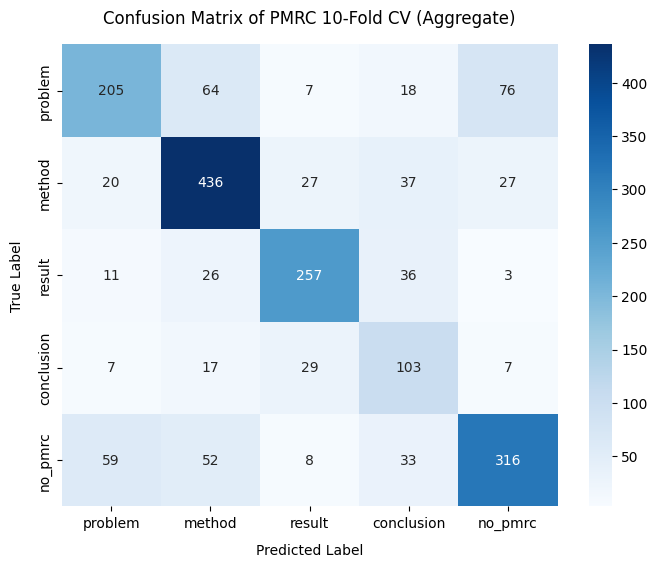

In [ ]:
# Menghitung Confusion Matrix dari akumulasi seluruh prediksi OOF
cm_all = confusion_matrix(y_true_all, y_pred_all)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_all, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix of PMRC 10-Fold CV (Aggregate)', pad=15)
plt.xlabel('Predicted Label', labelpad=10)
plt.ylabel('True Label', labelpad=10)
plt.show()

- Berdasarkan *confusion matrix* agregat, model secara umum berhasil mengidentifikasi pola mayoritas data yang ditunjukkan oleh tebalnya angka pada diagonal utama (kiri atas ke kanan bawah).  
- Prediksi benar (*True Positive*) tertinggi dicapai oleh kelas *method* (436 sampel), diikuti no_pmrc (316 sampel) dan result (257 sampel).
- Adanya ambiguitas semantik dan tumpang tindih karakteristik bahasa (*lexical overlap*) antar-kelas pada abstrak jurnal. Misklasifikasi paling menonjol terjadi pada kelas problem yang sering keliru diprediksi sebagai *no_pmrc* (76 sampel) dan *method* (64 sampel), serta kelas *conclusion* yang menjadi target kesalahan prediksi dari kelas* method* (37 sampel) dan *no_pmrc* (33 sampel).

In [ ]:
# Menampilkan Classification Report
print("\n----- Classification Report of PMRC 10-Fold CV (Aggregate) -----\n")
report = classification_report(y_true_all, y_pred_all, target_names=label_names)
print(report)


----- Classification Report of PMRC 10-Fold CV (Aggregate) -----

              precision    recall  f1-score   support

     problem       0.68      0.55      0.61       370
      method       0.73      0.80      0.76       547
      result       0.78      0.77      0.78       333
  conclusion       0.45      0.63      0.53       163
     no_pmrc       0.74      0.68      0.70       468

    accuracy                           0.70      1881
   macro avg       0.68      0.69      0.68      1881
weighted avg       0.71      0.70      0.70      1881



- Berdasarkan *classification report* agregat, model menghasilkan performa bervariasi antar-kelas dengan akurasi global stabil di angka 0.70.
- Kelas *result* berkinerja paling optimal dengan F1-score tertinggi 0.78 (precision 0.78, *recall* 0.77), diikuti oleh kelas *method* dengan F1-score 0.76 (*recall* 0.80).
- Kelas *conclusion* menjadi *bottleneck* dengan F1-score terendah 0.53 akibat rendahnya nilai *precision* (0.45) karena tingginya *false positive*.
- Kelas *problem* terkendala pada nilai *recall* yang rendah (0.55) meski memiliki *precision* cukup baik (0.68).
- Terdapat ketimpangan akibat variasi jumlah sampel (*support*), model tetap menunjukkan ketahanan yang baik dengan perolehan macro average F1-score sebesar 0.68.

#### D. Confidence Score

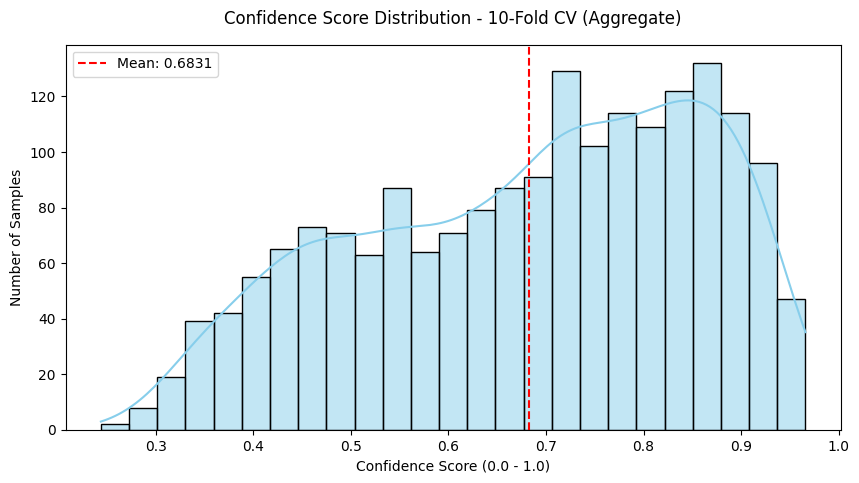

In [ ]:
# Visualisasi distribusi confidence score hasil prediksi akumulasi seluruh fold
plt.figure(figsize=(10, 5))
sns.histplot(all_confidences, bins=25, kde=True, color='skyblue')
plt.axvline(all_confidences.mean(), color='red', linestyle='--', label=f'Mean: {all_confidences.mean():.4f}')
plt.title('Confidence Score Distribution - 10-Fold CV (Aggregate)', pad=15)
plt.xlabel('Confidence Score (0.0 - 1.0)')
plt.ylabel('Number of Samples')
plt.legend()
plt.show()

Berdasarkan grafik di atas, distribusi skor kepercayaan (*confidence score*) hasil agregat menunjukkan tren yang positif dengan bentuk miring ke kiri (*negatively skewed*). Akumulasi sampel terbesar terpusat pada rentang skor tinggi antara 0.70 hingga 0.95, dengan puncak frekuensi di kisaran 0.85. Nilai rata-rata (Mean) yang berada di angka 0.6831 menegaskan bahwa sebagian besar keputusan klasifikasi diambil model dengan tingkat kepastian yang tinggi, sekaligus mengonfirmasi stabilitas dan keandalan model dalam memprediksi kelas target.

In [ ]:
# Menampilkan hasil prediksi dan confidence score
df_oof['is_correct'] = df_oof['label_pmrc'].str.lower() == df_oof['predicted_label'].str.lower()

# Seleksi fitur/kolom esensial untuk keperluan analisis hasil prediksi
display_columns = [
    'abstract_id',
    'sentence_no',
    'sentence_segment',
    'label_pmrc',
    'predicted_label',
    'confidence_score',
    'is_correct'
]

# Menampilkan representasi tabel sampel dari hasil prediksi Out-of-Fold (OOF)
print("\n" + "="*40)
print("  Prediction Results Out-of-Fold (OOF)")
print("="*40)
display(df_oof[display_columns].head(15))


  Prediction Results Out-of-Fold (OOF)


,abstract_id,sentence_no,sentence_segment,label_pmrc,predicted_label,confidence_score,is_correct
0,1,6,penelitian bersifat kualitatif dengan metode d...,method,method,0.902102,True
1,5,6,metode penelitian untuk pengembangan sistem in...,method,method,0.939801,True
2,6,1,semakin banyaknya jumlah pengguna internet sei...,no_pmrc,no_pmrc,0.769657,True
3,6,5,jenis penelitian pada penelitian in adalah res...,method,method,0.770163,True
4,7,2,tujuan penelitian ini adalah untuk mempermudah...,conclusion,conclusion,0.602986,True
5,7,5,"pada tahap pencarian, aplikasi akan meminta ak...",result,method,0.346808,False
6,12,1,menu santapan segar untuk pengidap diabet meli...,no_pmrc,no_pmrc,0.618156,True
7,12,5,santapan yang disantap oleh pengidap diabet wa...,problem,no_pmrc,0.513108,False
8,14,4,metode analisis digunakan untuk menganalisa si...,method,method,0.928075,True
9,16,4,hal inilah yang menginspirasi peneliti untuk m...,method,method,0.820083,True


Berdasarkan sampel tabel hasil prediksi *Out-of-Fold*(OOF), model dominan menghasilkan prediksi benar (*true*), khususnya pada kelas *method* dan *no_pmrc* dengan skor kepercayaan tinggi hingga mencapai 0.9398. Namun, misklasifikasi tetap terjadi pada beberapa segmen kalimat dengan tingkat kepercayaan yang cenderung lebih rendah (di bawah 0.55), seperti pada indeks 5 (kelas *result* terprediksi *method*) dan indeks 7 (kelas *problem* terprediksi *no_pmrc*). Hal ini menunjukkan adanya ambiguitas atau tumpang tindih karakteristik bahasa antar-kelas tertentu dalam abstrak jurnal.

#### E. Simpan Hasil Evaluasi Aggregate

In [ ]:
# Rekonstruksi log riwayat pelatihan ke dalam struktur kamus (dictionary) per fold
structured_logs = {}

for i, history in enumerate(all_fold_histories):
    structured_logs[f"fold_{i+1}"] = history

# Simpan Log Training (History)
with open(f"{BASE_PATH}/reports/all_folds_training_logs.json", "w") as f:
    json.dump(structured_logs, f, indent=4) # indent=4 agar file json mudah dibaca manusia

In [ ]:
# Ekspor data mentah yang digunakan sebagai basis pembagian Stratified K-Fold
data_pmrc.to_excel(f"{BASE_PATH}/results/full_dataset_for_kfold.xlsx", index=False)

# Ekspor akumulasi hasil prediksi Out-of-Fold (OOF)
df_oof.to_excel(f"{BASE_PATH}/results/oof_predictions_complete.xlsx", index=False)

### 9. Evaluasi Fold / Model Terbaik

Berdasarkan seluruh rangkaian eksperimen *10-Fold Cross-Validation*, Fold 8 terpilih sebagai checkpoint model terbaik dengan pencapaian metrik evaluasi tertinggi, yaitu skor F1-Macro sebesar 0.7267 dan Akurasi mencapai 0.7447.

In [ ]:
# A. Menampilkan rangkuman status performa dari model terbaik yang berhasil disimpan
print(f"🏆 Best Model Status: Fold {best_fold_number} (F1: {best_f1:.4f})")

🏆 Best Model Status: Fold 8 (F1: 0.7267)


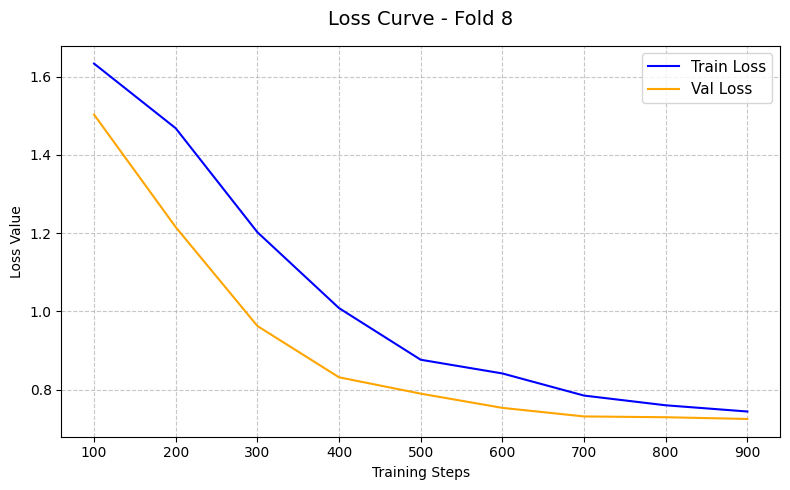

In [ ]:
# B. Loss Curve (Model Terbaik)

# Ekstraksi log riwayat pelatihan khusus untuk fold terbaik
best_history = all_fold_histories[best_fold_number - 1]

# Ekstrak metrik loss beserta langkah (steps) pasangannya dari model terbaik
train_steps = [e['step'] for e in best_history if 'loss' in e]
train_loss = [e['loss'] for e in best_history if 'loss' in e]

val_steps = [e['step'] for e in best_history if 'eval_loss' in e]
val_loss = [e['eval_loss'] for e in best_history if 'eval_loss' in e]

# Pembuatan grafik kurva loss tunggal untuk model terbaik
plt.figure(figsize=(8, 5))

# Plotting kurva Train Loss dan Validation Loss berbasis urutan steps
plt.plot(train_steps, train_loss, label='Train Loss', color='blue')
plt.plot(val_steps, val_loss, label='Val Loss', color='orange')

# Konfigurasi penanda interval (ticks) pada sumbu X berdasarkan akumulasi langkah
all_steps = sorted(list(set(train_steps + val_steps)))
plt.xticks(all_steps)

# Pengaturan elemen anotasi, label, dan grid grafik
plt.title(f'Loss Curve - Fold {best_fold_number}', fontsize=14, pad=15)
plt.xlabel('Training Steps')
plt.ylabel('Loss Value')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Mengatur tata letak dan menampilkan visualisasi grafik
plt.tight_layout()
plt.show()

Berdasarkan grafik kurva loss pada Fold 8, model menunjukkan proses pembelajaran yang ideal dan konvergen. Baik *Train Loss* (garis biru) maupun *Val Loss* (garis orange) menurun secara selaras tanpa indikasi overfitting, dengan titik stabil tercapai pada rentang steps 700 hingga 900. Jarak (*gap*) antar-kurva yang sangat tipis dan nilai validasi akhir membuktikan kemampuan generalisasi data yang sangat baik, sekaligus memvalidasi keputusan pemilihan fold ini sebagai checkpoint terbaik.

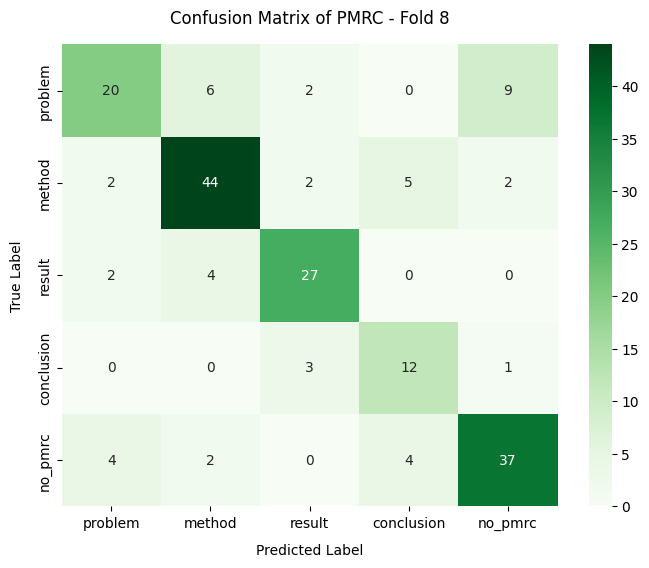

In [ ]:
# C. Confusion Matrix
# Ekstraksi array nilai untuk label aktual dan label prediksi khusus dari fold terbaik
y_true_best = best_oof_df['label'].values
y_pred_best = best_oof_df['predicted_label'].map(label2id).values

# Menghitung Confusion Matrix untuk model terbaik
cm_best = confusion_matrix(y_true_best, y_pred_best)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix of PMRC - Fold {best_fold_number}', pad=15)
plt.xlabel('Predicted Label', labelpad=10)
plt.ylabel('True Label', labelpad=10)
plt.show()

Berdasarkan *confusion matrix* Fold 8, model ini menunjukkan performa klasifikasi yang andal dengan keunggulan prediksi benar tertinggi terpusat pada diagonal utama, dipimpin oleh kelas *method* (44 sampel), *no_pmrc* (37 sampel), dan *result* (27 sampel). Ambiguitas bahasa terkendali secara minor, dengan misklasifikasi terbesar hanya terjadi pada kelas *problem* yang keliru diprediksi sebagai *no_pmrc* sebanyak 9 sampel. Secara keseluruhan, visualisasi ini membuktikan efektivitas tinggi Fold 8 dalam meminimalkan kesalahan prediksi di setiap kategori target.

In [ ]:
# D. Classification Report
print(f"\n----- Classification Report of PMRC - Fold {best_fold_number} -----\n")
report_best = classification_report(y_true_best, y_pred_best, target_names=label_names)
print(report_best)


----- Classification Report of PMRC - Fold 8 -----

              precision    recall  f1-score   support

     problem       0.71      0.54      0.62        37
      method       0.79      0.80      0.79        55
      result       0.79      0.82      0.81        33
  conclusion       0.57      0.75      0.65        16
     no_pmrc       0.76      0.79      0.77        47

    accuracy                           0.74       188
   macro avg       0.72      0.74      0.73       188
weighted avg       0.75      0.74      0.74       188



Berdasarkan *classification report* Fold 8, model ini mencatatkan akurasi sebesar 0.74 dan macro average F1-score 0.73. Kelas *result* menjadi kategori paling optimal dengan skor F1 mencapai 0.81, disusul oleh *method* (0.79) dan *no_pmrc* (0.77). Berbeda dari tren agregat, kelas *conclusion* pada fold ini berhasil meningkatkan nilai *recall* secara signifikan hingga 0.75 meskipun presisinya masih tertahan di 0.57. Sebaliknya, kendala deteksi kini bergeser ke kelas *problem* yang mencatatkan nilai *recall* terendah sebesar 0.54, walaupun ketepatan prediksinya (*precision*) cukup tinggi di angka 0.71.

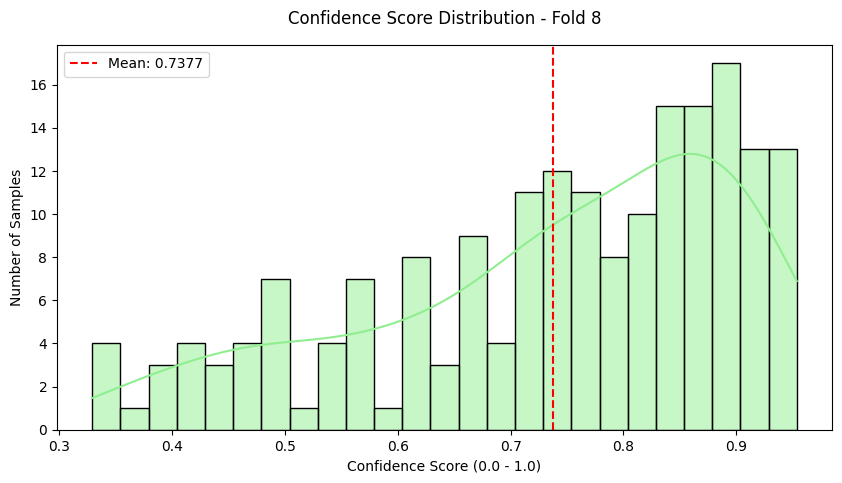

In [ ]:
# E. Visualisasi distribusi confidence score hasil prediksi dari fold terbaik
plt.figure(figsize=(10, 5))
confidences_best = best_oof_df['confidence_score'].values
sns.histplot(confidences_best, bins=25, kde=True, color='lightgreen')
plt.axvline(confidences_best.mean(), color='red', linestyle='--', label=f'Mean: {confidences_best.mean():.4f}')
plt.title(f'Confidence Score Distribution - Fold {best_fold_number}', pad=15)
plt.xlabel('Confidence Score (0.0 - 1.0)')
plt.ylabel('Number of Samples')
plt.legend()
plt.show()

Berdasarkan grafik di atas, distribusi skor kepercayaan (*confidence score*) pada Fold 8 miring ke kiri (*negatively skewed*) dengan akumulasi sampel terbesar terpusat pada rentang tinggi antara 0.70 hingga 0.95 dan puncak di kisaran 0.90. Nilai rata-rata yang meningkat hingga angka 0.7377 menegaskan bahwa model terbaik ini mengambil mayoritas keputusan klasifikasi dengan tingkat kepastian yang tinggi, mengungguli rata-rata performa agregat.

In [ ]:
# Menampilkan hasil prediksi dan confidence score dari fold terbaik
display_columns = [
    'abstract_id',
    'sentence_no',
    'sentence_segment',
    'label_pmrc',
    'predicted_label',
    'confidence_score',
    'is_correct'
]

print("\n" + "="*45)
print(f"  Prediction Results (Best Model - Fold {best_fold_number})")
print("="*45)
display(best_oof_df[display_columns].head(15))


  Prediction Results (Best Model - Fold 8)


,abstract_id,sentence_no,sentence_segment,label_pmrc,predicted_label,confidence_score,is_correct
0,2,2,sebagai upaya untuk mengefisienkan proses bisn...,problem,problem,0.329193,True
1,4,5,hasil dari penelitian ini nilai accuracy terti...,result,result,0.948859,True
2,6,3,semakin banyak situs yang kurang mendidik pada...,problem,problem,0.664835,True
3,7,3,metode yang digunakan dalam penelitian ini ada...,method,method,0.910310,True
4,9,1,"untuk memproses basis data rdbms, sudah umum d...",method,method,0.741377,True
5,9,8,metode penelitian yang digunakan adalah model ...,method,method,0.904135,True
6,10,2,"tidak jarang pula, akhirnya aplikasi apache sp...",problem,problem,0.734389,True
7,10,6,metode penelitian yang digunakan adalah model ...,method,method,0.904135,True
8,10,7,hasil luaran penelitian ini adalah sebuah sist...,result,result,0.810395,True
9,13,3,metode yang digunakan pada penelitian ini adal...,method,method,0.919575,True


Berdasarkan sampel data tabel Fold 8, model menghasilkan akurasi yang tinggi dengan dominasi prediksi benar, terutama pada kelas *method* dan *result* yang berhasil diidentifikasi dengan skor kepercayaan mencapai 0.9488. Meskipun demikian, kesalahan kecil berupa *false positive* tetap muncul pada batas keputusan yang ambigu, seperti pada indeks 11 (kelas *result* keliru diprediksi sebagai *method*) dan indeks 14 (kelas *method* salah diidentifikasi sebagai *problem* dengan skor rendah 0.4138).

#### Simpan Hasil Evaluasi Model Terbaik

In [ ]:
# Ekspor subset data training yang digunakan oleh fold dengan performa terbaik
best_train_df.to_excel(f"{BASE_PATH}/results/best_model_train_data.xlsx", index=False)

# Ekspor hasil prediksi dari subset validasi khusus milik fold dengan performa terbaik
best_oof_df.to_excel(f"{BASE_PATH}/results/best_model_predictions.xlsx", index=False)

## BAGIAN 2: INFERENCE MODEL

### 📌 Panduan Menjalankan Inference Model

Untuk menjalankan kode inference ini, silakan ikuti langkah-langkah berikut secara berurutan:

1. Persiapan File:
    - Unduh file `indobert-pmrc.zip` (model) dari repositori GitHub ini ke komputer Anda.
    - (Opsional) Jika Anda ingin menggunakan metode input Excel, siapkan juga file .xlsx dataset Anda.

2. Unggah ke Colab:
    - Buka menu Files (ikon folder di sebelah kiri layar Colab).
    - Seret dan lepas (drag and drop) file `indobert-pmrc.zip` ke dalam panel Files tersebut.

3. Tunggu Unggahan:
    - Pastikan indikator loading di bagian bawah panel kiri Colab benar-benar hilang/selesai (100%). Jangan menjalankan sel kode sebelum unggahan selesai agar file tidak rusak.

4. Eksekusi:
    - Jalankan setiap sel kode di bawah ini secara berurutan dari nomor 1 sampai selesai.
    - Ikuti instruksi yang muncul di layar (misalnya saat memilih metode input manual atau Excel).

5. Hasil:
    - Setelah proses prediksi selesai, sistem akan menampilkan tabel hasil dan secara otomatis memicu unduhan file prediction_results.xlsx ke komputer Anda.

### 1. Instalasi dan Persiapan Lingkungan

In [1]:
!pip install -q transformers torch openpyxl nltk

In [2]:
# Import library
import os
import shutil
import torch
import textwrap
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import nltk
from nltk.tokenize import sent_tokenize
from transformers import BertTokenizerFast, BertForSequenceClassification
import torch.nn.functional as F

# Mengaktifkan format tabel interaktif
from google.colab import data_table, files
data_table.enable_dataframe_formatter()

In [3]:
# Mengunduh modul punkt untuk pemisahan kalimat
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [4]:
# Menentukan device (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ Menggunakan device: {device}")


✅ Menggunakan device: cuda


### 2. Load Model

In [5]:
# 1. Tentukan path file zip dan folder tujuan ekstraksi
zip_path = "/content/indobert-pmrc.zip"
extract_dir = "/content/indobert-pmrc-extracted"

# 2. Ekstrak file zip jika belum diekstrak
if os.path.exists(zip_path):
    if not os.path.exists(extract_dir):
        print(f"Mengekstrak {zip_path}...")
        shutil.unpack_archive(zip_path, extract_dir)
        print("✅ Ekstraksi selesai!")

    # Deteksi otomatis path model
    possible_path = os.path.join(extract_dir, "indobert-pmrc/model")
    model_path = possible_path if os.path.exists(possible_path) else extract_dir

    print(f"Memuat model dari: {model_path}")
    tokenizer = BertTokenizerFast.from_pretrained(model_path)
    model = BertForSequenceClassification.from_pretrained(model_path).to(device)
    model.eval()
    print("✅ Model berhasil dimuat!")
else:
    print("❌ File indobert-pmrc.zip tidak ditemukan di /content/")

Mengekstrak /content/indobert-pmrc.zip...
✅ Ekstraksi selesai!
Memuat model dari: /content/indobert-pmrc-extracted/indobert-pmrc/model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model berhasil dimuat!


### 3. Fungsi Inference Interaktif

In [8]:
# List untuk menampung seluruh abstrak
abstract_list = []

print("===================================")
print("            INPUT ABSTRAK          ")
print("===================================\n")
print("Pilih metode input data:")
print("1. Ketik/paste teks abstrak secara manual")
print("2. Baca dari file Excel (.xlsx)")
choice = input("\nMasukkan pilihan (1 atau 2): ").strip()

if choice == '1':
    print("\n--- Mode Ketik/Paste Manual ---")
    print("1. Ketik/paste teks abstrak satu per satu.")
    print("2. Ketik 'exit' untuk selesai dan lanjut ke prediksi.")

    while True:
        text_input = input("\nMasukkan abstrak: ")
        if text_input.strip().lower() == 'exit':
            break

        if text_input.strip():
            abstract_list.append(text_input)
            print("\n[Pratinjau Abstrak]:")
            wrapped_text = textwrap.fill(text_input, width=100)
            print(wrapped_text)
            print("-" * 100)
            print(f"✅ Abstrak ke-{len(abstract_list)} ditambahkan.")
elif choice == '2':
    excel_path = input("Masukkan path file Excel (contoh: /content/data.xlsx): ").strip()
    col_name = input("Masukkan nama kolom teks: ").strip()
    df_excel = pd.read_excel(excel_path)
    abstract_list = df_excel[col_name].dropna().astype(str).tolist()

# Fungsi inference
def run_inference(list_teks):
    segmented_data = []
    for idx, text in enumerate(list_teks, start=1):
        for s_no, sent in enumerate(sent_tokenize(text), start=1):
            segmented_data.append({'abstract_id': idx, 'sentence_no': s_no, 'sentence_segment': sent})

    df = pd.DataFrame(segmented_data)
    sentences = df['sentence_segment'].tolist()

    all_preds, all_conf = [], []
    for i in tqdm(range(0, len(sentences), 16)):
        batch = tokenizer(sentences[i:i+16], padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = model(**batch).logits
            probs = F.softmax(logits, dim=-1)
            conf, preds = torch.max(probs, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_conf.extend(conf.cpu().numpy())

    df['predicted_label'] = [model.config.id2label[p] for p in all_preds]
    df['confidence_score'] = all_conf
    return df

# 3. Jalankan fungsi
df_result = run_inference(abstract_list)

if not df_result.empty:
    pd.set_option('display.max_colwidth', None)
    display(df_result.head(20))

    save_path = "/content/prediction_results.xlsx"
    df_result.to_excel(save_path, index=False)
    print(f"\n✅ Selesai! Mengunduh file...")
    files.download(save_path)

            INPUT ABSTRAK          

Pilih metode input data:
1. Ketik/paste teks abstrak secara manual
2. Baca dari file Excel (.xlsx)

Masukkan pilihan (1 atau 2): 1

--- Mode Ketik/Paste Manual ---
1. Ketik/paste teks abstrak satu per satu.
2. Ketik 'exit' untuk selesai dan lanjut ke prediksi.

Masukkan abstrak: Dalam pengembangan perangkat lunak, tantangan dalam hal efisiensi dan efektivitas sering kali muncul, terutama ketika menghadapi keterbatasan sumber daya untuk memenuhi tujuan kebutuhan pengguna. Studi ini bertujuan untuk menyelidiki berbagai pendekatan untuk pengembangan perangkat lunak, termasuk berbagai pendekatan, seperti Waterfall, Prototyping, dan Quick Application Improvement (RAD), dengan penekanan pada peningkatan efisiensi dalam proses pengembangan. Dengan menggunakan metode Waterfall, Prototyping, Rapid Application Development (RAD), dan melalui analisis kualitatif, penelitian ini dapat membedakan preferensi dan kekurangan dari masing-masing strategi yang dapat di

  0%|          | 0/1 [00:00<?, ?it/s]

,abstract_id,sentence_no,sentence_segment,predicted_label,confidence_score
0,1,1,"Dalam pengembangan perangkat lunak, tantangan dalam hal efisiensi dan efektivitas sering kali muncul, terutama ketika menghadapi keterbatasan sumber daya untuk memenuhi tujuan kebutuhan pengguna.",problem,0.565343
1,1,2,"Studi ini bertujuan untuk menyelidiki berbagai pendekatan untuk pengembangan perangkat lunak, termasuk berbagai pendekatan, seperti Waterfall, Prototyping, dan Quick Application Improvement (RAD), dengan penekanan pada peningkatan efisiensi dalam proses pengembangan.",method,0.773419
2,1,3,"Dengan menggunakan metode Waterfall, Prototyping, Rapid Application Development (RAD), dan melalui analisis kualitatif, penelitian ini dapat membedakan preferensi dan kekurangan dari masing-masing strategi yang dapat dianalisis berdasarkan studi literatur yang ada.",method,0.568772
3,1,4,"Metode Waterfall menawarkan kemudahan dalam manajemen proyek, meskipun memiliki fleksibilitas yang terbatas.",conclusion,0.650264
4,1,5,"Di sisi lain, prototyping mendukung identifikasi kebutuhan yang berulang, namun cenderung mahal.",problem,0.397640
5,1,6,"Sementara itu, pendekatan Rapid Application Development (RAD) dapat mempercepat proses pengembangan, tetapi kurang ideal untuk proyek-proyek berisiko tinggi.",problem,0.616931
6,1,7,Pemilihan metodologi yang tepat harus diselaraskan dengan kebutuhan spesifik dari pengembangan yang dilakukan untuk mengoptimalkan efisiensi dan kualitas program yang dibuat.,problem,0.389309
7,2,1,Tugas akhir merupakan salah satu syarat yang harus dipenuhi oleh mahasiswa untuk menyelesaikan pendidikan di perguruan tinggi.,no_pmrc,0.837539
8,2,2,"Data judul tugas akhir mahasiswa Program Studi Ilmu Komputer pada Sistem Informasi Akademik (SIMAK) Universitas Pakuan masih didata berdasarkan periode kelulusan mahasiswa dan belum diklasifikasikan berdasarkan topik tugas akhir dan akan bertambah seiring dengan jumlah kelulusan setiap semesternya, sehingga mahasiswa yang akan melaksanakan tugas akhir kesulitan dalam mencari referensi judul-judul tugas akhir yang sesuai dengan topiknya.",problem,0.807194
9,2,3,"Maka dari itu, penelitian ini bertujuan untuk membuat sistem klasifikasi topik tugas akhir mahasiswa mengunakan algoritma Extreme Gradient Boosting (XGBoost).",method,0.889967



✅ Selesai! Mengunduh file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>